## Access Satellite Austemp Heatwave 8Day (Zarr)
This Jupyter notebook demonstrates how to access and plot satellite_austemp_heatwave_8day data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/2ffccdad-1197-4e41-b412-a9033517cfb2).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/satellite_austemp_heatwave_8day.ipynb).


In [1]:
dataset_name = "satellite_austemp_heatwave_8day"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 201 packages in 58ms
Checked 201 packages in 1ms


✅ Virtual environment already exists, skipping creation.
✅ Local version 0.3.25 is up to date (remote: 0.3.18)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4679: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 936 ms, sys: 80.9 ms, total: 1.02 s
Wall time: 2.34 s


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	time = 5225 ;
	lat = 2000 ;
	lon = 3900 ;

variables:
	float64 MCS_category(time, lat, lon) ;
		MCS_category:comment = Marine cold spell category defined as per Hobday et al., 2018 ;
		MCS_category:flag_meanings = none moderate strong severe extreme ;
		MCS_category:flag_values = [0, 1, 2, 3, 4] ;
		MCS_category:long_name = Marine Cold Spell Category ;
		MCS_category:source = 20120101152000-ABOM-L3S_GHRSST-SSTskin-MultiSensor-1d_night.nc, SSTAARS_daily_fit_001.nc ;
		MCS_category:valid_max = 4 ;
		MCS_category:valid_min = 0 ;
	float64 MCS_category_mosaic(time, lat, lon) ;
		MCS_category_mosaic:comment = Marine cold spell category defined as per Hobday et al., 2018 for 14 day SST Mosaic ;
		MCS_category_mosaic:flag_meanings = none moderate strong severe extreme ;
		MCS_category_mosaic:flag_values = [0, 1, 2, 3, 4] ;
		MCS_category_mosaic:long_name = Mosaic Marine Cold Spell Category ;
		MCS_category_mosaic:source = 20120101152000-ABOM-L3S_GHRSST-SSTskin-Mul

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2012-01-01 00:00:00'), Timestamp('2026-04-21 00:00:00'))

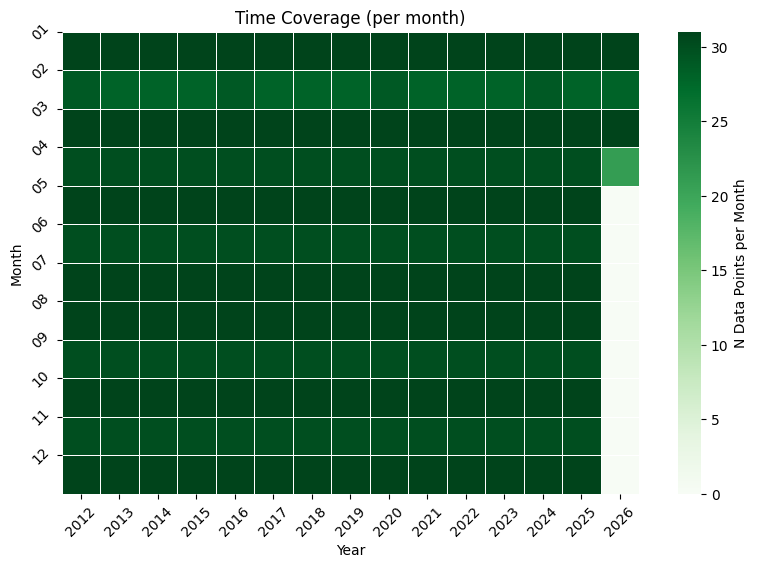

In [7]:
aodn_dataset.plot_time_coverage()

## Timeseries at a point

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:2220: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled = df[self.var_name].resample(resample)


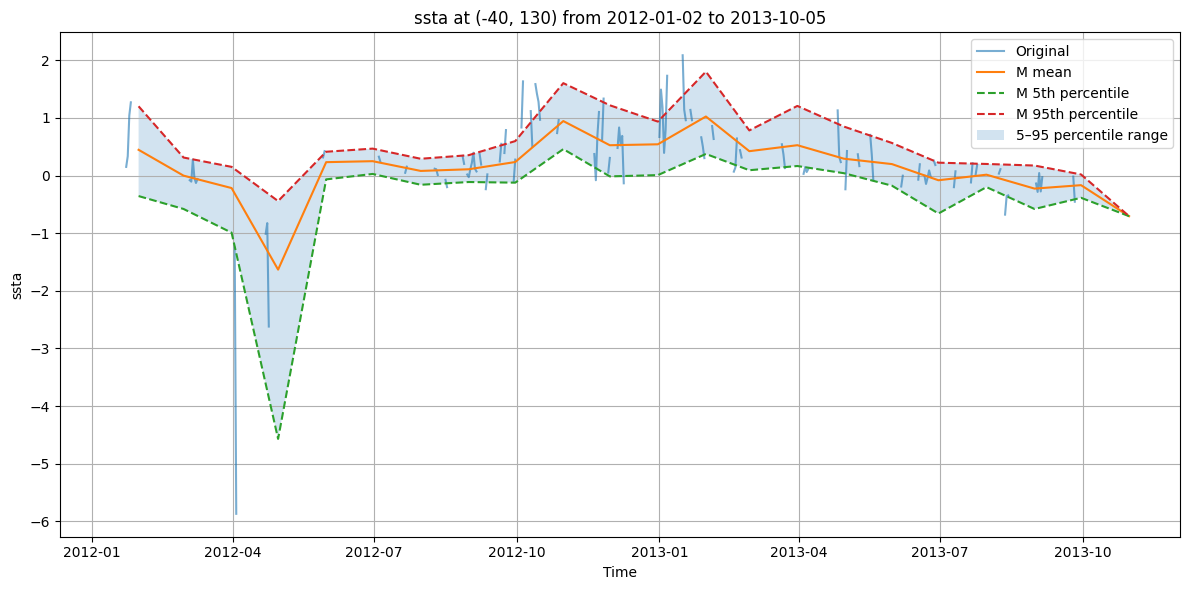

CPU times: user 8.54 s, sys: 3.04 s, total: 11.6 s
Wall time: 1min


In [8]:
%%time
time_series_df = aodn_dataset.get_timeseries_data(var_name='ssta', 
                                                  lat=-40, 
                                                  lon=130, 
                                                  date_start='2012-01-02', 
                                                  date_end='2013-10-05', 
                                                  lon_name_override="lon", 
                                                  lat_name_override="lat").plot_timeseries()

## Plot a gridded variable

2026-06-03 14:47:07,248 - aodn.GetAodn - INFO - Plotting 'Sea Surface Sub-skin Temperature Anomaly' for 6 time steps.
/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:3785: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


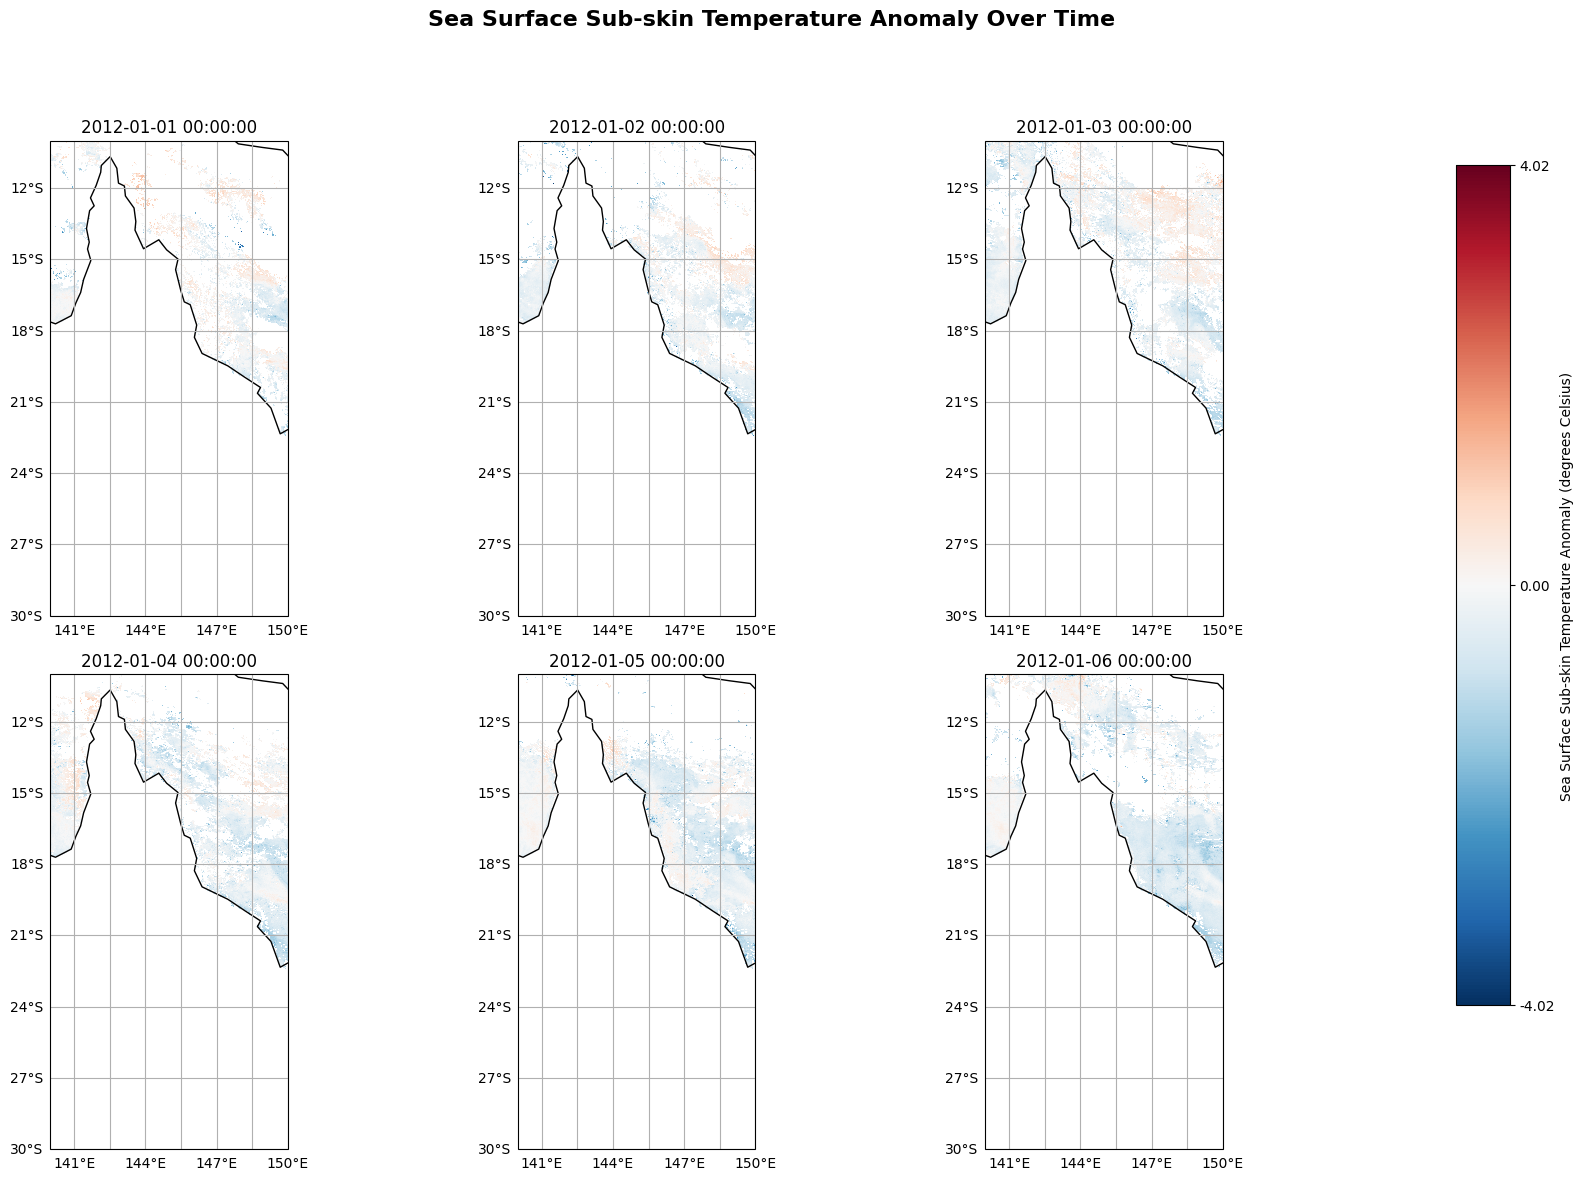

CPU times: user 13 s, sys: 5.59 s, total: 18.6 s
Wall time: 1min 38s


In [9]:
%%time
time_series_df = aodn_dataset.plot_gridded_variable(var_name='ssta', 
                                                    date_start='2012-01-01',                                                
                                                    lon_slice=(140, 150), 
                                                    lat_slice=(-30, -10), 
                                                    n_days=6, 
                                                    coastline_resolution="110m", 
                                                    log_scale=False,
                                                    plot_type='anomaly',
)

2026-06-03 14:48:46,331 - aodn.GetAodn - INFO - Plotting 'Marine Cold Spell Category' for 6 time steps.
/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:3785: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


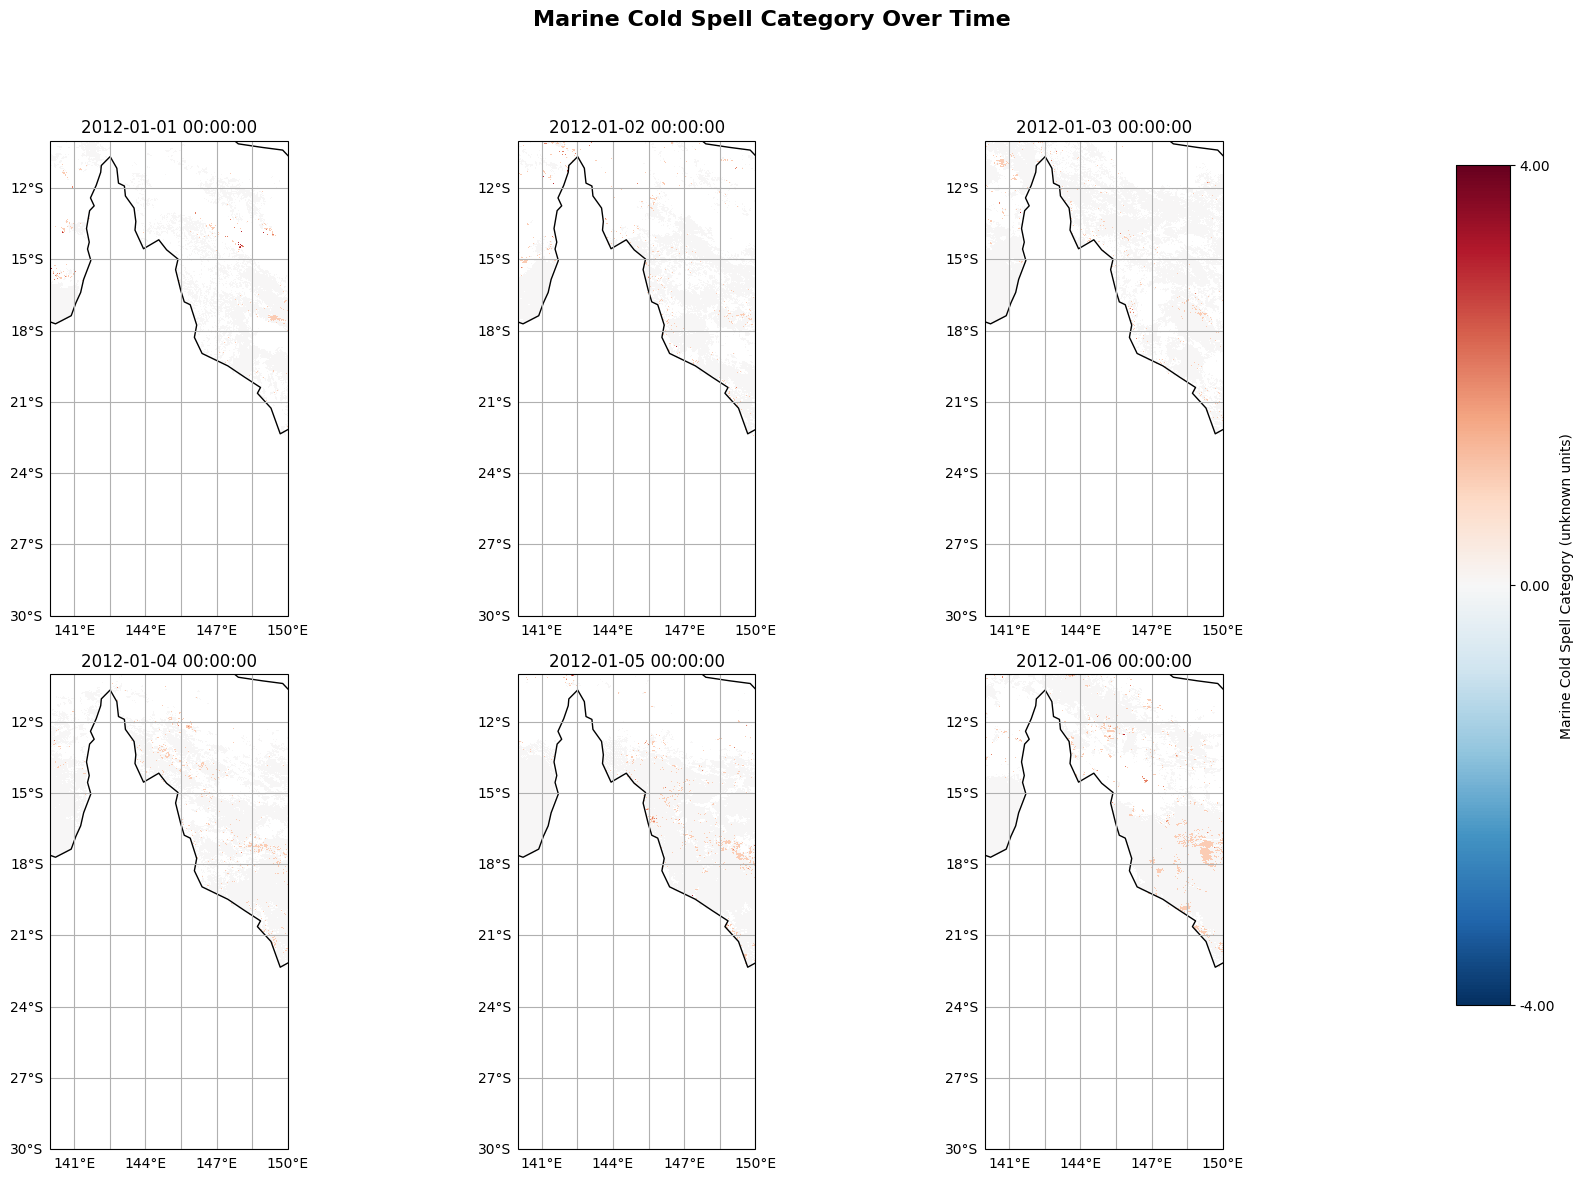

CPU times: user 8.39 s, sys: 4.29 s, total: 12.7 s
Wall time: 20.1 s


In [10]:
%%time
time_series_df = aodn_dataset.plot_gridded_variable(var_name='MCS_category', 
                                                    date_start='2012-01-01',                                                
                                                    lon_slice=(140, 150), 
                                                    lat_slice=(-30, -10), 
                                                    n_days=6, 
                                                    coastline_resolution="110m", 
                                                    log_scale=False,
                                                    plot_type='anomaly',
)